## Librairies et fixation de la graine aléatoire

In [ ]:
install.packages("corrplot")
library(ggplot2)
library(corrplot)
library(dplyr)
library(MASS)
library(glmnet)
library(randomForest)
library(nnet)

set.seed(42)

## Importation des données, vérification de leur dimension et de leur complétude.

In [3]:
data = read.csv("YearPredictionMSD.csv", header = T, stringsAsFactors=T)

dim(data)

na.vect = colSums(is.na(data))
#Pas de donnée manquante NA

na.vect

[1] 515345     91

Year         TimbreAvg1         TimbreAvg2         TimbreAvg3 
                 0                  0                  0                  0 
        TimbreAvg4         TimbreAvg5         TimbreAvg6         TimbreAvg7 
                 0                  0                  0                  0 
        TimbreAvg8         TimbreAvg9        TimbreAvg10        TimbreAvg11 
                 0                  0                  0                  0 
       TimbreAvg12  TimbreCovariance1  TimbreCovariance2  TimbreCovariance3 
                 0                  0                  0                  0 
 TimbreCovariance4  TimbreCovariance5  TimbreCovariance6  TimbreCovariance7 
                 0                  0                  0                  0 
 TimbreCovariance8  TimbreCovariance9 TimbreCovariance10 TimbreCovariance11 
                 0                  0                  0                  0 
TimbreCovariance12 TimbreCovariance13 TimbreCovariance14 TimbreCovariance15 
                 0                  0                  0                  0 
TimbreCovariance16 TimbreCovariance17 TimbreCovariance18 TimbreCovariance19 
                 0                  0                  0                  0 
TimbreCovariance20 TimbreCovariance21 TimbreCovariance22 TimbreCovariance23 
                 0                  0                  0                  0 
TimbreCovariance24 TimbreCovariance25 TimbreCovariance26 TimbreCovariance27 
                 0                  0                  0                  0 
TimbreCovariance28 TimbreCovariance29 TimbreCovariance30 TimbreCovariance31 
                 0                  0                  0                  0 
TimbreCovariance32 TimbreCovariance33 TimbreCovariance34 TimbreCovariance35 
                 0                  0                  0                  0 
TimbreCovariance36 TimbreCovariance37 TimbreCovariance38 TimbreCovariance39 
                 0                  0                  0                  0 
TimbreCovariance40 TimbreCovariance41 TimbreCovariance42 TimbreCovariance43 
                 0                  0                  0                  0 
TimbreCovariance44 TimbreCovariance45 TimbreCovariance46 TimbreCovariance47 
                 0                  0                  0                  0 
TimbreCovariance48 TimbreCovariance49 TimbreCovariance50 TimbreCovariance51 
                 0                  0                  0                  0 
TimbreCovariance52 TimbreCovariance53 TimbreCovariance54 TimbreCovariance55 
                 0                  0                  0                  0 
TimbreCovariance56 TimbreCovariance57 TimbreCovariance58 TimbreCovariance59 
                 0                  0                  0                  0 
TimbreCovariance60 TimbreCovariance61 TimbreCovariance62 TimbreCovariance63 
                 0                  0                  0                  0 
TimbreCovariance64 TimbreCovariance65 TimbreCovariance66 TimbreCovariance67 
                 0                  0                  0                  0 
TimbreCovariance68 TimbreCovariance69 TimbreCovariance70 TimbreCovariance71 
                 0                  0                  0                  0 
TimbreCovariance72 TimbreCovariance73 TimbreCovariance74 TimbreCovariance75 
                 0                  0                  0                  0 
TimbreCovariance76 TimbreCovariance77 TimbreCovariance78 
                 0                  0                  0

## Statistiques exploratoires et distribution de la variable cible

In [4]:
cat(sprintf("Min        : %d\n",   min(data$Year)))
cat(sprintf("Max        : %d\n",   max(data$Year)))
cat(sprintf("Moyenne    : %.2f\n", mean(data$Year)))
cat(sprintf("Mediane    : %.2f\n", median(data$Year)))
cat(sprintf("Ecart-type : %.2f\n", sd(data$Year)))

Min        : 1922
Max        : 2011
Moyenne    : 1998.40
Mediane    : 2002.00
Ecart-type : 10.93


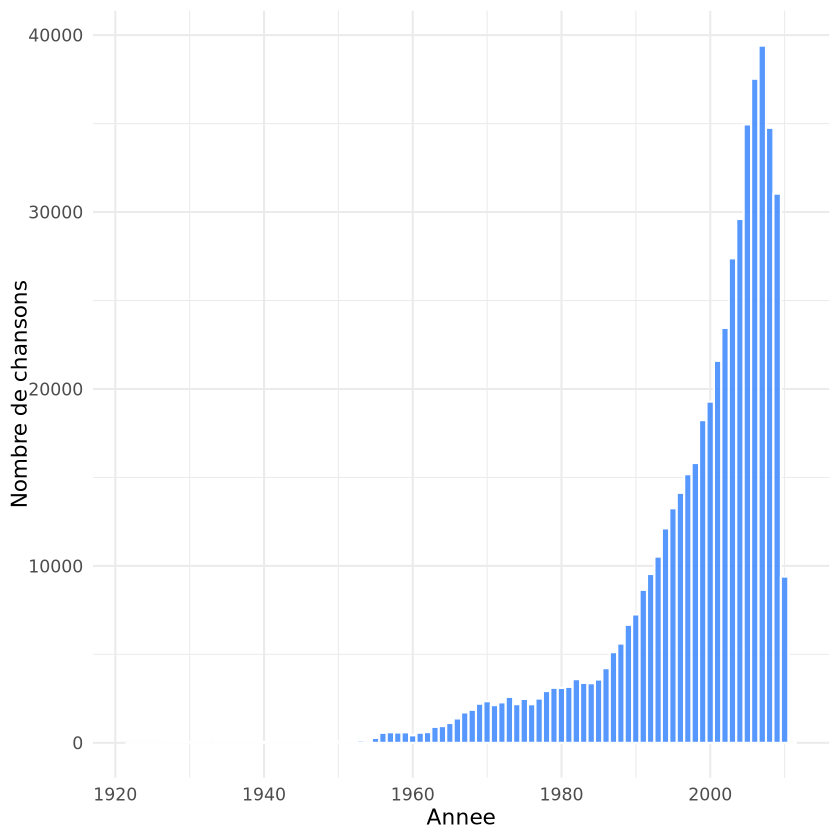

In [5]:
p1 <- ggplot(data, aes(x = Year)) +
  geom_histogram(binwidth = 1, fill = "#3A86FF", color = "white", alpha = 0.85) +
  labs( x = "Annee", y = "Nombre de chansons") +
  theme_minimal(base_size = 13) +
  theme(plot.title = element_text(face = "bold"))
 
ggsave("plot_03a_histogramme_year.png", p1, width = 9, height = 5, dpi = 150)
print(p1)

## Choix d'échantillonnage
Observation de la distribution de la variable prédictive Year en fonction de la taille du sample. On choisit le jeu de données le plus petit possible en respectant la distribution initiale.

[1] 5000   91

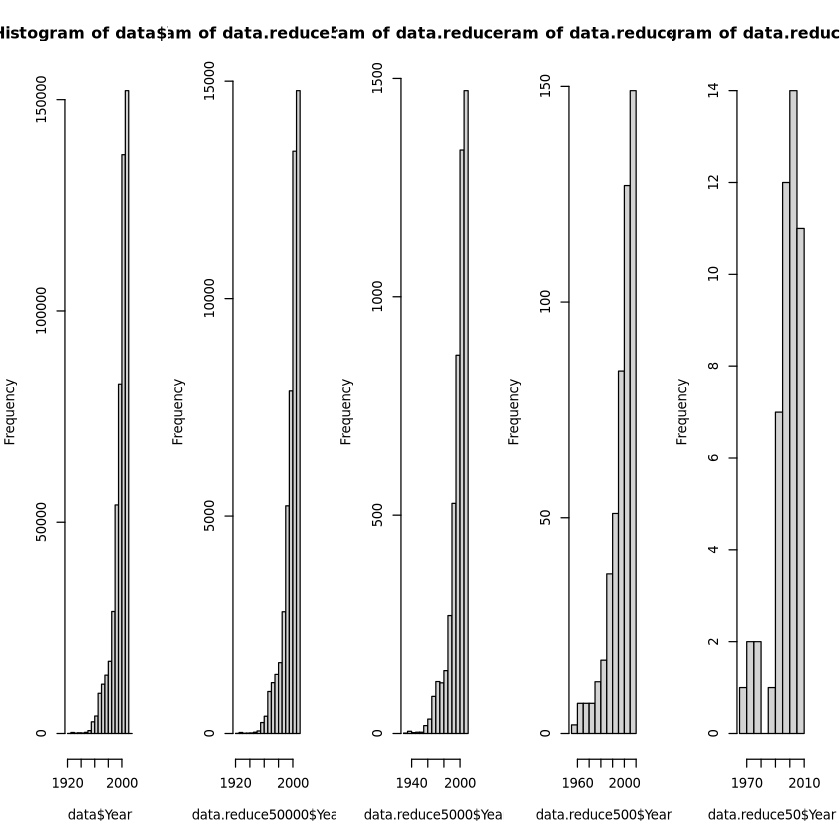

In [6]:
index.reduce50000 = sample(1:nrow(data), size = 50000, replace = F)
index.reduce5000= sample(1:nrow(data), size = 5000, replace = F)
index.reduce500= sample(1:nrow(data), size = 500, replace = F)
index.reduce50= sample(1:nrow(data), size = 50, replace = F)

data.reduce50000 = data[index.reduce50000,]
data.reduce5000 = data[index.reduce5000,]
data.reduce500 = data[index.reduce500,]
data.reduce50 = data[index.reduce50,]

data.reduce = data.reduce5000 #choix du jeu de données à 5000 individus

dim(data.reduce)
par(mfrow = c(1,5))
hist(data$Year)
hist(data.reduce50000$Year)
hist(data.reduce5000$Year)
hist(data.reduce500$Year)
hist(data.reduce50$Year)
par(mfrow = c(1,1))

## Observations sur la correlation

#### Corrélation sur les variables TimbreAvg

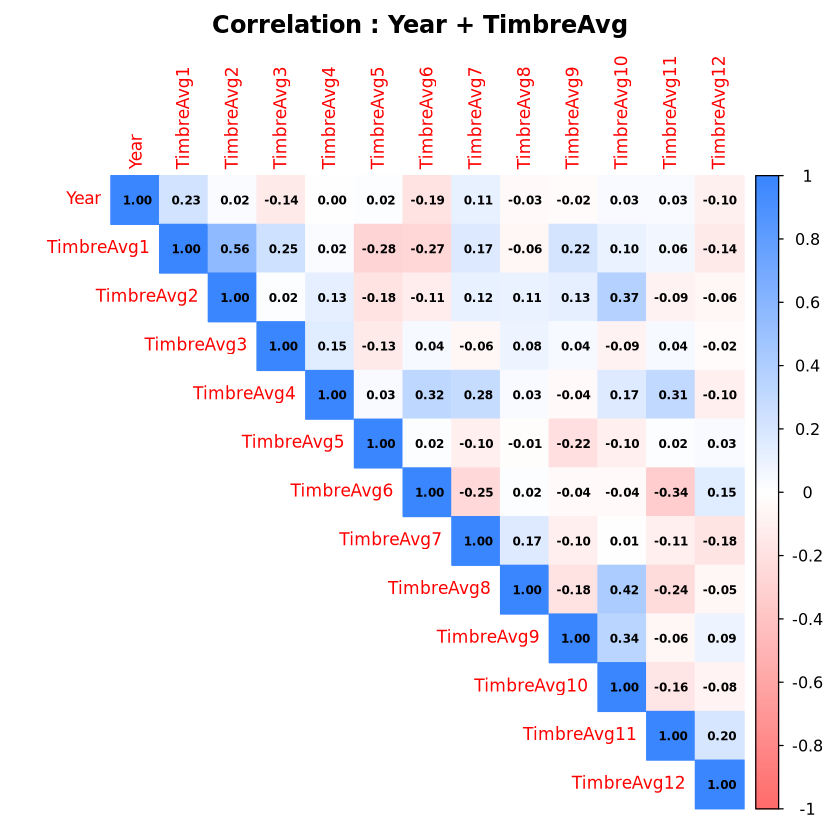

In [7]:
avg_cols <- paste0("TimbreAvg", 1:12)

mat <- cor(data[, c("Year", avg_cols)], use = "complete.obs")

corrplot(mat,
         method      = "color",
         type        = "upper",
         tl.cex      = 0.85,
         addCoef.col = "black",
         number.cex  = 0.6,
         col         = colorRampPalette(c("#FF6B6B", "white", "#3A86FF"))(200),
         title       = "Correlation : Year + TimbreAvg",
         mar         = c(0, 0, 2, 0))

#### Correlation sur les variables TimbreCovariance
Utilisation d'une représentation différente, adaptée aux nombres de variable.

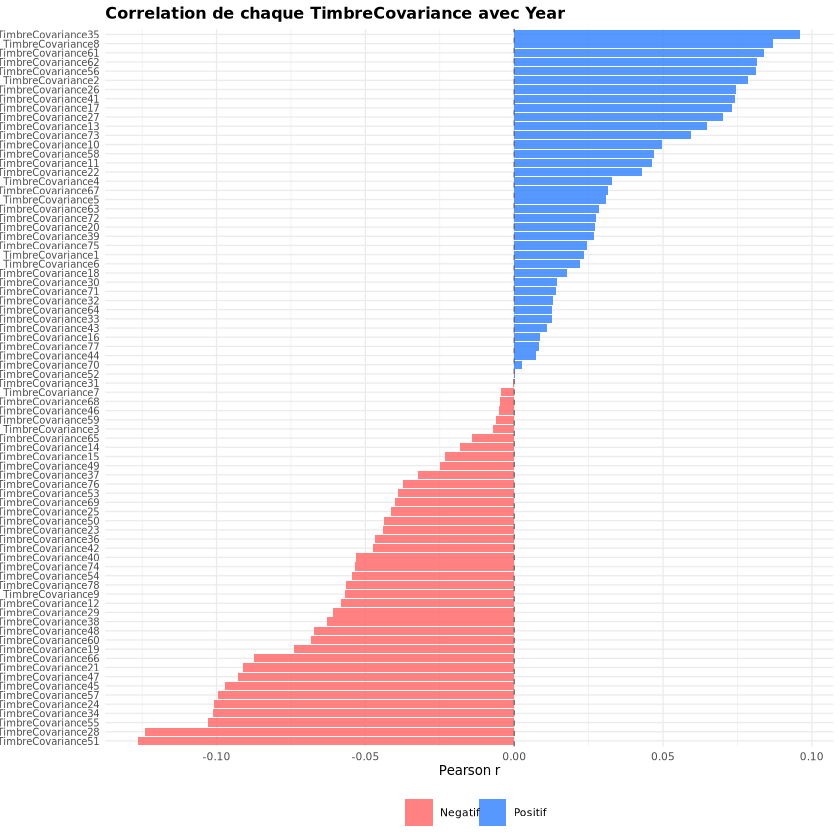

In [8]:
cov_cols <- paste0("TimbreCovariance", 1:78)

corr_cov <- cor(data[, c("Year", cov_cols)], use = "complete.obs")["Year", cov_cols]

corr_cov_df <- data.frame(
  feature     = names(corr_cov),
  correlation = round(as.numeric(corr_cov), 4)
) %>% arrange(desc(abs(correlation)))


ggplot(corr_cov_df, aes(x = reorder(feature, correlation), y = correlation,
                         fill = correlation > 0)) +
  geom_col(alpha = 0.85) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "grey40") +
  scale_fill_manual(values = c("#FF6B6B", "#3A86FF"),
                    labels = c("Negatif", "Positif")) +
  coord_flip() +
  labs(title = "Correlation de chaque TimbreCovariance avec Year",
       x = NULL, y = "Pearson r", fill = "") +
  theme_minimal(base_size = 8) +
  theme(plot.title      = element_text(face = "bold"),
        legend.position = "bottom",
        axis.text.y     = element_text(size = 6))

### Découpage train/test

In [10]:
index.test = sample(1:nrow(data.reduce), size=0.2*nrow(data.reduce), replace=F)
reduce.test=data.reduce[index.test,]
reduce.train=data.reduce[-index.test,]

### Modèle simple
Sélection de variables selon les plus fortes correlations avec "Year".

In [11]:
modSimple = lm(Year ~ TimbreAvg1 + TimbreAvg6 + TimbreCovariance35 +
               TimbreCovariance51 + TimbreCovariance28 + TimbreCovariance55,
               data = reduce.train)

### Sélection avec stepAIC

In [12]:
modreduce=lm(Year ~ ., data=reduce.train)
modStep = stepAIC(modreduce, trace=FALSE)

In [13]:
summary(modStep)


Call:
lm(formula = Year ~ TimbreAvg1 + TimbreAvg2 + TimbreAvg3 + TimbreAvg4 + 
    TimbreAvg5 + TimbreAvg6 + TimbreAvg8 + TimbreAvg9 + TimbreAvg10 + 
    TimbreAvg11 + TimbreCovariance1 + TimbreCovariance2 + TimbreCovariance4 + 
    TimbreCovariance6 + TimbreCovariance7 + TimbreCovariance10 + 
    TimbreCovariance11 + TimbreCovariance12 + TimbreCovariance13 + 
    TimbreCovariance14 + TimbreCovariance15 + TimbreCovariance16 + 
    TimbreCovariance17 + TimbreCovariance20 + TimbreCovariance21 + 
    TimbreCovariance24 + TimbreCovariance26 + TimbreCovariance27 + 
    TimbreCovariance29 + TimbreCovariance31 + TimbreCovariance34 + 
    TimbreCovariance36 + TimbreCovariance39 + TimbreCovariance40 + 
    TimbreCovariance41 + TimbreCovariance45 + TimbreCovariance46 + 
    TimbreCovariance47 + TimbreCovariance48 + TimbreCovariance50 + 
    TimbreCovariance52 + TimbreCovariance53 + TimbreCovariance57 + 
    TimbreCovariance62 + TimbreCovariance63 + TimbreCovariance66 + 
    TimbreCovariance68 +

Nombre de variables retenues avec stepAIC

In [14]:
length(coef(modStep)) - 1

[1] 53

#### Métriques de comparaison sur le modèle réduit et stepAIC

In [15]:
summary(modreduce)$adj.r.squared
summary(modStep)$adj.r.squared

[1] 0.2190302

[1] 0.223484

In [16]:
AIC(modreduce)
AIC(modStep)

[1] 29318.4

[1] 29259.21

In [17]:
BIC(modreduce)
BIC(modStep)

[1] 29897.46

[1] 29605.38

### Régularisation LASSO

[1] 0.04516204

91 x 1 sparse Matrix of class "dgCMatrix"
                              s1
(Intercept)         1.955329e+03
TimbreAvg1          8.312893e-01
TimbreAvg2         -4.929234e-02
TimbreAvg3         -4.075637e-02
TimbreAvg4         -1.064032e-02
TimbreAvg5         -5.526978e-03
TimbreAvg6         -1.454405e-01
TimbreAvg7          .           
TimbreAvg8         -1.076345e-01
TimbreAvg9         -7.203347e-02
TimbreAvg10         7.060461e-02
TimbreAvg11        -1.419238e-01
TimbreAvg12        -8.754588e-03
TimbreCovariance1   2.105371e-02
TimbreCovariance2   4.472642e-04
TimbreCovariance3  -1.350755e-05
TimbreCovariance4   4.069013e-04
TimbreCovariance5   .           
TimbreCovariance6   5.361393e-04
TimbreCovariance7   2.279320e-03
TimbreCovariance8   8.176693e-04
TimbreCovariance9   1.136440e-03
TimbreCovariance10  6.924801e-04
TimbreCovariance11  6.480432e-03
TimbreCovariance12  1.937893e-03
TimbreCovariance13 -2.348933e-03
TimbreCovariance14 -1.659299e-04
TimbreCovariance15  5.288155e-04
T

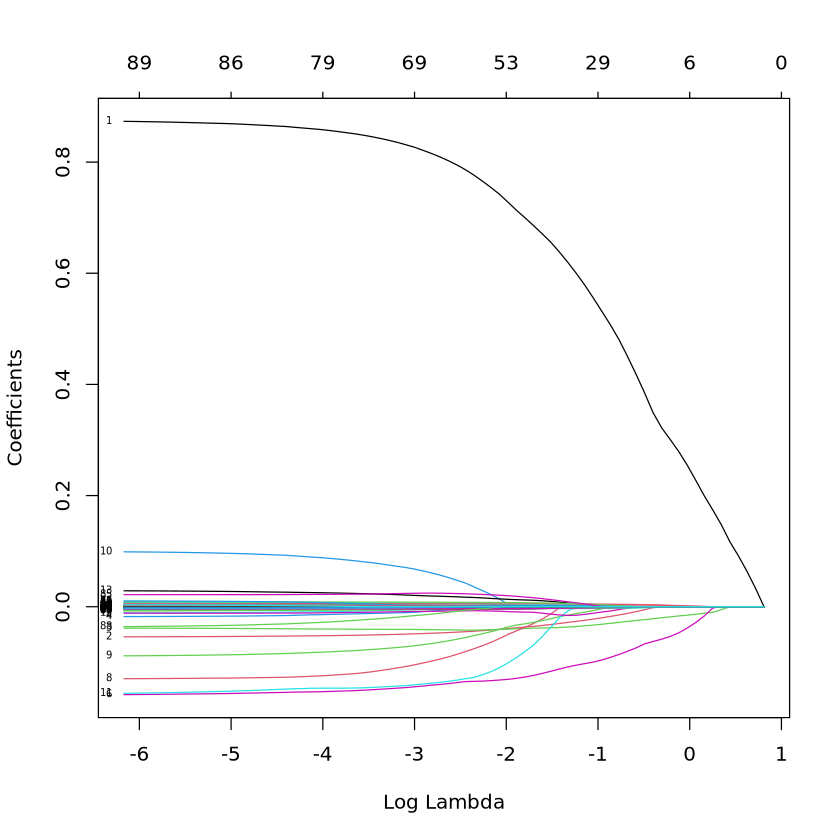

In [18]:
y = as.matrix(data.reduce$Year)
x = as.matrix(data.reduce[,-1])
fit = glmnet(x,y)
plot(fit, xvar="lambda", label=T)

#lasso
cvfit = cv.glmnet(x,y)
cvfit$lambda.min
coef(cvfit, s = "lambda.min")

In [19]:
# Evaluation LASSO sur le jeu de test réduit
x_test_lasso <- as.matrix(reduce.test[, -1])
pred_lasso   <- as.vector(predict(cvfit, newx = x_test_lasso, s = "lambda.min"))

mse_lasso <- mean((reduce.test$Year - pred_lasso)^2)
r2_lasso  <- 1 - sum((reduce.test$Year - pred_lasso)^2) /
                 sum((reduce.test$Year - mean(reduce.test$Year))^2)

cat("LASSO - MSE :", round(mse_lasso, 2), "\n")
cat("LASSO - R2  :", round(r2_lasso,  4), "\n")

LASSO - MSE : 78.29 
LASSO - R2  : 0.2366 


### Intersection du modèle par régularisation de LASSO et du modèle stepAIC

In [20]:
vars_step = names(coef(modStep))[-1]

lasso_coefs = coef(cvfit, s = "lambda.min")
vars_lasso = rownames(lasso_coefs)[which(lasso_coefs != 0)]
vars_lasso = vars_lasso[vars_lasso != "(Intercept)"]

vars_intersection = intersect(vars_step, vars_lasso)
length(vars_intersection)

[1] 52

In [21]:
print(vars_intersection)

 [1] "TimbreAvg1"         "TimbreAvg2"         "TimbreAvg3"        
 [4] "TimbreAvg4"         "TimbreAvg5"         "TimbreAvg6"        
 [7] "TimbreAvg8"         "TimbreAvg9"         "TimbreAvg10"       
[10] "TimbreAvg11"        "TimbreCovariance1"  "TimbreCovariance2" 
[13] "TimbreCovariance4"  "TimbreCovariance6"  "TimbreCovariance7" 
[16] "TimbreCovariance10" "TimbreCovariance11" "TimbreCovariance12"
[19] "TimbreCovariance13" "TimbreCovariance14" "TimbreCovariance15"
[22] "TimbreCovariance16" "TimbreCovariance17" "TimbreCovariance20"
[25] "TimbreCovariance21" "TimbreCovariance24" "TimbreCovariance26"
[28] "TimbreCovariance27" "TimbreCovariance29" "TimbreCovariance31"
[31] "TimbreCovariance34" "TimbreCovariance36" "TimbreCovariance39"
[34] "TimbreCovariance40" "TimbreCovariance41" "TimbreCovariance45"
[37] "TimbreCovariance46" "TimbreCovariance47" "TimbreCovariance50"
[40] "TimbreCovariance52" "TimbreCovariance53" "TimbreCovariance57"
[43] "TimbreCovariance62" "TimbreCovariance63" "

In [50]:
vars_intersection = c("TimbreAvg1", "TimbreAvg2", "TimbreAvg3", "TimbreAvg4", "TimbreAvg5", "TimbreAvg6", "TimbreAvg8", "TimbreAvg9", "TimbreAvg10", 
                      "TimbreAvg11", "TimbreCovariance1", "TimbreCovariance2", "TimbreCovariance4", "TimbreCovariance6", "TimbreCovariance7", "TimbreCovariance10",
                      "TimbreCovariance11", "TimbreCovariance12", "TimbreCovariance13", "TimbreCovariance14", "TimbreCovariance15", "TimbreCovariance16", "TimbreCovariance17",
                      "TimbreCovariance20", "TimbreCovariance21", "TimbreCovariance24", "TimbreCovariance26", "TimbreCovariance27", "TimbreCovariance29", "TimbreCovariance31", 
                      "TimbreCovariance34", "TimbreCovariance36", "TimbreCovariance39", "TimbreCovariance40", "TimbreCovariance41", "TimbreCovariance45", "TimbreCovariance46", 
                      "TimbreCovariance47", "TimbreCovariance50", "TimbreCovariance52", "TimbreCovariance53", "TimbreCovariance57", "TimbreCovariance62", "TimbreCovariance63",
                      "TimbreCovariance66", "TimbreCovariance68", "TimbreCovariance71", "TimbreCovariance72", "TimbreCovariance73", "TimbreCovariance75", "TimbreCovariance76", "TimbreCovariance77")
formule_inter = as.formula(paste("Year ~", paste(vars_intersection, collapse = "+")))
modInter = lm(formule_inter, data = reduce.train)

In [59]:
inter_r2 <- summary(modInter)$adj.r.squared
pred_inter <- predict(modInter, newdata = reduce.test)

mse_inter <- mean((reduce.test$Year - pred_inter)^2)

### Test de normalité sur les résidus et métriques de comparaison sur les modèles

In [23]:
shapiro.test(residuals(modSimple))
shapiro.test(residuals(modInter))
shapiro.test(residuals(modreduce))


	Shapiro-Wilk normality test

data:  residuals(modSimple)
W = 0.86291, p-value < 2.2e-16



	Shapiro-Wilk normality test

data:  residuals(modInter)
W = 0.88072, p-value < 2.2e-16



	Shapiro-Wilk normality test

data:  residuals(modreduce)
W = 0.88649, p-value < 2.2e-16


In [24]:
AIC(modreduce) ; AIC(modInter) ; AIC(modSimple)

[1] 29318.4

[1] 29324.8

[1] 29978.28

In [25]:
BIC(modreduce) ; BIC(modInter) ; BIC(modSimple)

[1] 29897.46

[1] 29608.03

[1] 30028.64

In [26]:
summary(modreduce)$adj.r.squared
summary(modInter)$adj.r.squared
summary(modSimple)$adj.r.squared

[1] 0.2190302

[1] 0.2086953

[1] 0.05965624

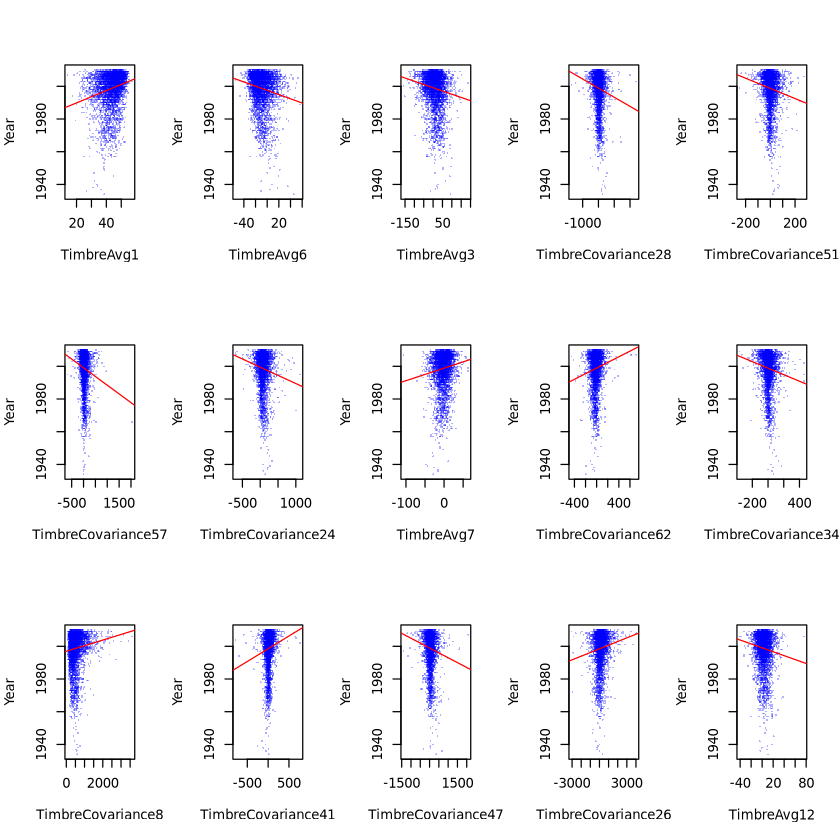

In [27]:
avg_cols = paste0("TimbreAvg", 1:12)
cov_cols = paste0("TimbreCovariance", 1:78)
all_cols = c(avg_cols, cov_cols)

cor_all = cor(data.reduce[, all_cols], data.reduce$Year)
cor_df  = data.frame(var = rownames(cor_all), r = as.numeric(cor_all))
cor_df  = cor_df[order(abs(cor_df$r), decreasing = TRUE), ]
top15   = cor_df$var[1:15]

par(mfrow = c(3, 5))
for (v in top15) {
    plot(data.reduce[[v]], data.reduce$Year,
         xlab = v, ylab = "Year",
         pch = 16, cex = 0.3, col = rgb(0,0,1,0.3))
    abline(lm(Year ~ data.reduce[[v]], data = data.reduce), col = "red")
}
par(mfrow = c(1, 1))

### Simplification du jeu de données à une période plus courte

[1] 474926     91

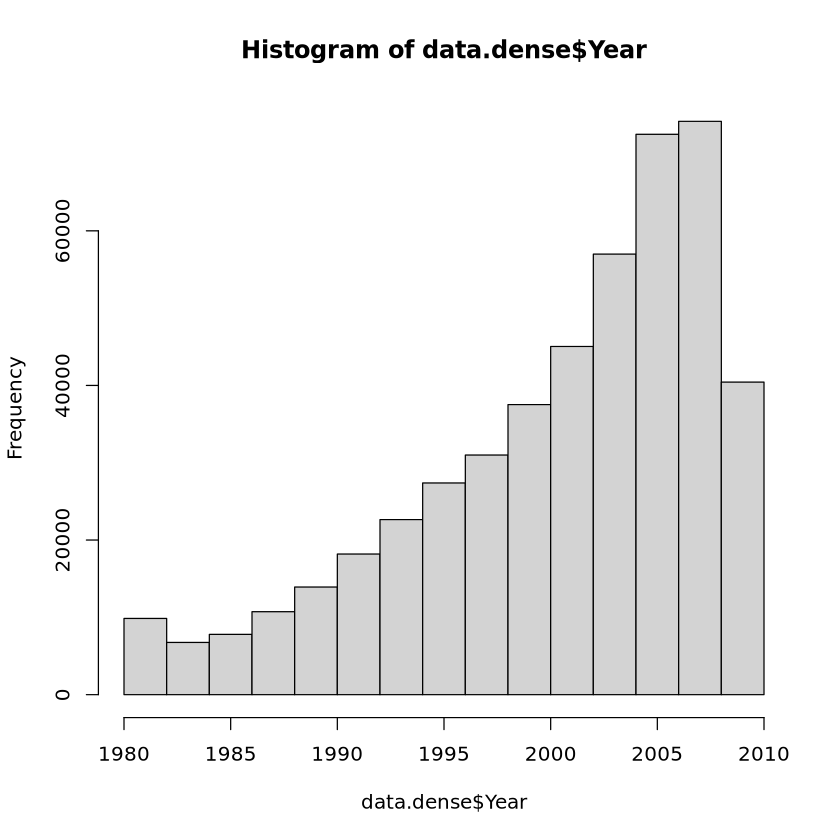

In [28]:
data.dense = data[data$Year >= 1980 & data$Year <= 2010, ]
dim(data.dense)
hist(data.dense$Year)

### Réduction du nombre d'individu
On confirme la préservation de la variable prédictive.

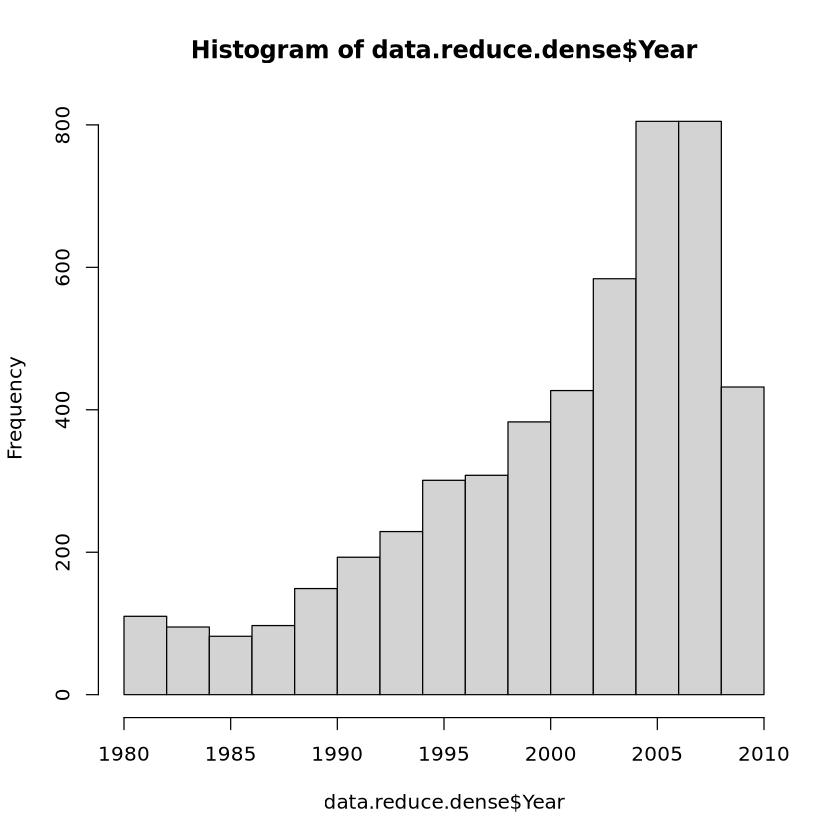

In [29]:
index.dense    <- sample(1:nrow(data.dense), size = 5000, replace = F)
data.reduce.dense <- data.dense[index.dense, ]
hist(data.reduce.dense$Year)

In [30]:
index.test.dense   <- sample(1:nrow(data.reduce.dense),
                              size = 0.2 * nrow(data.reduce.dense), replace = F)
reduce.test.dense  <- data.reduce.dense[index.test.dense, ]
reduce.train.dense <- data.reduce.dense[-index.test.dense, ]

In [31]:
y = as.matrix(reduce.train.dense$Year)
x = as.matrix(reduce.train.dense[, -1])
cvfit.dense = cv.glmnet(x, y)
cvfit.dense$lambda.min
coef(cvfit.dense, s = "lambda.min")

[1] 0.02368482

91 x 1 sparse Matrix of class "dgCMatrix"
                              s1
(Intercept)         1.962698e+03
TimbreAvg1          7.300767e-01
TimbreAvg2         -5.474670e-02
TimbreAvg3         -2.131202e-02
TimbreAvg4         -1.606595e-03
TimbreAvg5          .           
TimbreAvg6         -1.235059e-01
TimbreAvg7         -2.471170e-02
TimbreAvg8         -2.783393e-02
TimbreAvg9         -4.650825e-02
TimbreAvg10        -1.582625e-02
TimbreAvg11        -2.583470e-01
TimbreAvg12         3.018596e-02
TimbreCovariance1   2.631321e-02
TimbreCovariance2   1.689619e-04
TimbreCovariance3  -1.230744e-04
TimbreCovariance4   3.660645e-04
TimbreCovariance5  -6.200242e-04
TimbreCovariance6   1.165052e-03
TimbreCovariance7   2.138209e-03
TimbreCovariance8   1.745399e-03
TimbreCovariance9   1.125451e-03
TimbreCovariance10  .           
TimbreCovariance11  1.080957e-03
TimbreCovariance12  3.031178e-03
TimbreCovariance13 -1.737512e-03
TimbreCovariance14 -1.609689e-04
TimbreCovariance15  3.646500e-04
T

In [33]:
modComplet.dense = lm(Year ~ ., data = reduce.train.dense)
modStep.dense    = stepAIC(modComplet.dense, direction = "both", trace = FALSE)
length(coef(modStep.dense)) - 1

[1] 56

In [34]:
vars_step.dense  = names(coef(modStep.dense))[-1]
lasso_coefs.dense = coef(cvfit.dense, s = "lambda.min")
vars_lasso.dense  = rownames(lasso_coefs.dense)[which(lasso_coefs.dense != 0)]
vars_lasso.dense  = vars_lasso.dense[vars_lasso.dense != "(Intercept)"]
vars_inter.dense  = intersect(vars_step.dense, vars_lasso.dense)
length(vars_inter.dense)

[1] 55

In [35]:
modSimple.dense = lm(Year ~ TimbreAvg1 + TimbreAvg6 + TimbreCovariance35 +
                     TimbreCovariance51 + TimbreCovariance28 + TimbreCovariance55,
                     data = reduce.train.dense)

In [36]:
formule_inter.dense = as.formula(paste("Year ~", paste(vars_inter.dense, collapse = "+")))
modInter.dense = lm(formule_inter.dense, data = reduce.train.dense)

AIC(modComplet.dense) ; AIC(modInter.dense) ; AIC(modSimple.dense)
BIC(modComplet.dense) ; BIC(modInter.dense) ; BIC(modSimple.dense)
summary(modComplet.dense)$adj.r.squared
summary(modInter.dense)$adj.r.squared
summary(modSimple.dense)$adj.r.squared

[1] 25979.36

[1] 25929.69

[1] 26915.66

[1] 26558.41

[1] 26288.45

[1] 26966.01

[1] 0.2643388

[1] 0.2671524

[1] 0.05083379

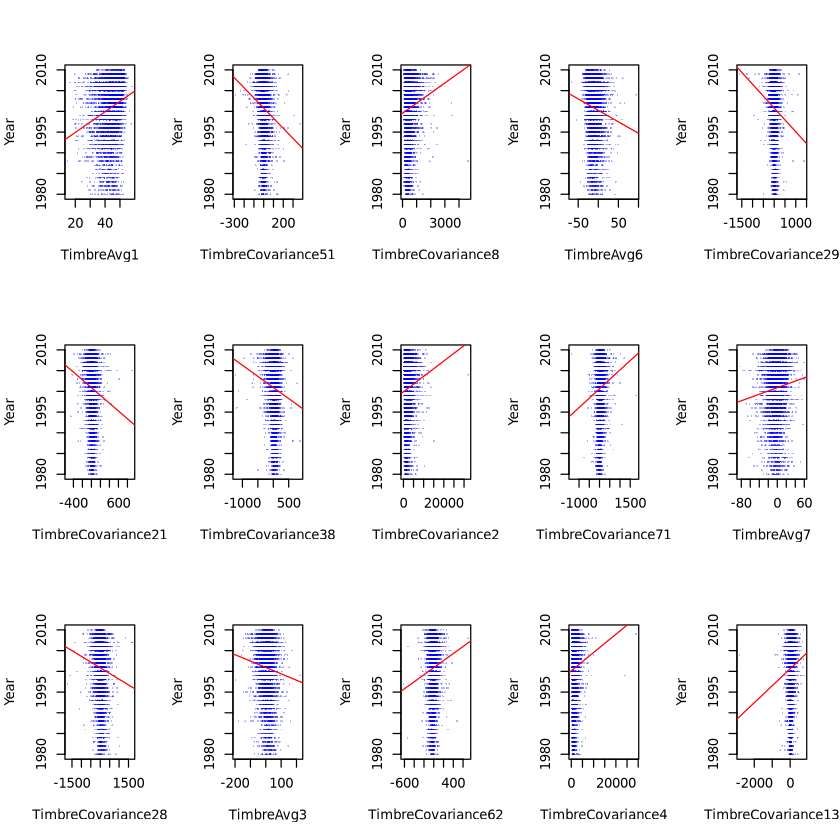

In [37]:
all_cols = c(paste0("TimbreAvg", 1:12), paste0("TimbreCovariance", 1:78))
cor_all  = cor(data.reduce.dense[, all_cols], data.reduce.dense$Year)
cor_df   = data.frame(var = rownames(cor_all), r = as.numeric(cor_all))
cor_df   = cor_df[order(abs(cor_df$r), decreasing = TRUE), ]
top15    = cor_df$var[1:15]

par(mfrow = c(3, 5))
for (v in top15) {
    plot(data.reduce.dense[[v]], data.reduce.dense$Year,
         xlab = v, ylab = "Year",
         pch = 16, cex = 0.3, col = rgb(0, 0, 1, 0.3))
    abline(lm(Year ~ data.reduce.dense[[v]], data = data.reduce.dense), col = "red")
}
par(mfrow = c(1, 1))

# Random Forest 

In [38]:
mod_rf <- randomForest(Year ~ ., data = reduce.train, ntree = 200, mtry = 30)

pred_rf <- predict(mod_rf, newdata = reduce.test)
mse_rf  <- mean((reduce.test$Year - pred_rf)^2)
r2_rf   <- 1 - sum((reduce.test$Year - pred_rf)^2) / sum((reduce.test$Year - mean(reduce.test$Year))^2)

cat("Random Forest - MSE:", round(mse_rf, 2), " R2:", round(r2_rf, 4), "\n")

Random Forest - MSE: 83.09  R2: 0.1898 


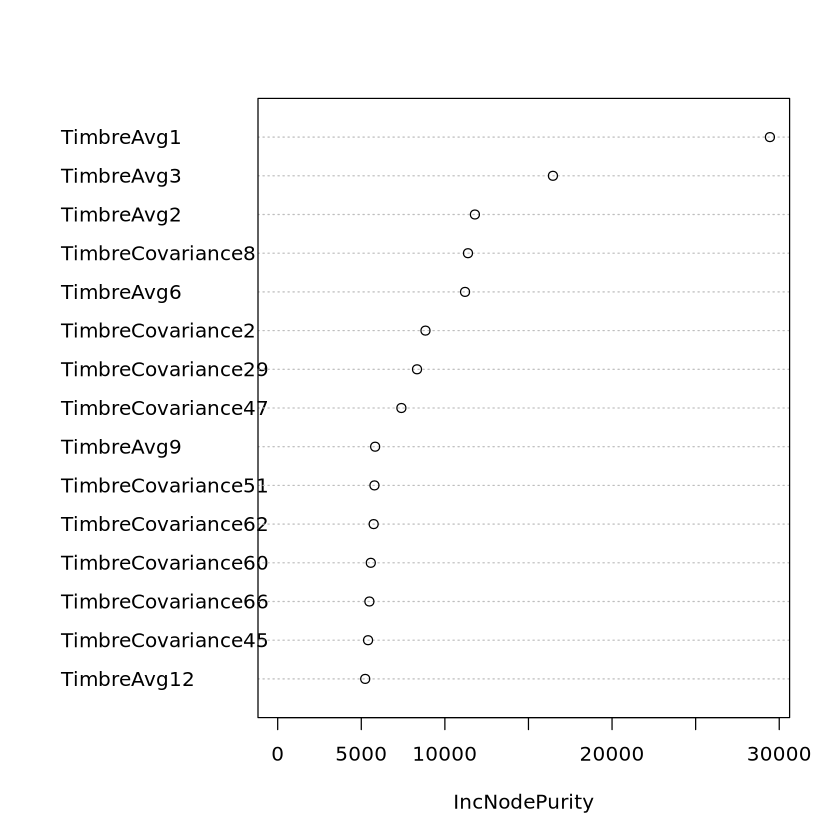

In [39]:
# Variables les plus importantes selon le Random Forest
varImpPlot(mod_rf, n.var = 15, main = "")

# Réseau de neurones

In [40]:
cols_nn <- c("Year", vars_intersection)

x_train_sc <- scale(as.matrix(reduce.train[, vars_intersection]))
x_test_sc  <- scale(as.matrix(reduce.test[,  vars_intersection]),
                    center = attr(x_train_sc, "scaled:center"),
                    scale  = attr(x_train_sc, "scaled:scale"))

r2 <- function(y, yhat) 1 - sum((y-yhat)^2) / sum((y-mean(y))^2)

configs <- list(
  c(5,  0.001),
  c(5,  0.01),
  c(8,  0.001),
  c(8,  0.01),
  c(10, 0.001),
  c(10, 0.01)
)

for (cfg in configs) {
  mod <- nnet(x_train_sc, reduce.train$Year,
              size   = cfg[1],
              linout = TRUE,
              maxit  = 500,
              decay  = cfg[2],
              trace  = FALSE)
  pred <- as.vector(predict(mod, x_test_sc))
  mse  <- mean((reduce.test$Year - pred)^2)
  r2v  <- r2(reduce.test$Year, pred)
  cat("size=", cfg[1], " decay=", cfg[2],
      " -> MSE:", round(mse, 2), " R2:", round(r2v, 4), "\n")
}

size= 5  decay= 0.001  -> MSE: 1768.45  R2: -16.2433 
size= 5  decay= 0.01  -> MSE: 2861.32  R2: -26.8994 
size= 8  decay= 0.001  -> MSE: 4868.26  R2: -46.4681 
size= 8  decay= 0.01  -> MSE: 135.04  R2: -0.3167 
size= 10  decay= 0.001  -> MSE: 84.1  R2: 0.18 
size= 10  decay= 0.01  -> MSE: 47885.04  R2: -465.9041 


## Nouvelle approche : decoupage officiel du dataset

Le découpage aleatoire sur 5000 observations introduit un biais : des chansons 
du meme artiste peuvent se retrouver à la fois dans le train et le test. 
Les auteurs du dataset recommandent un decoupage temporel officiel :
- Train : 463 715 premieres observations
- Test  :  51 630 dernieres observations
Ce decoupage garantit qu'aucun artiste n'apparait dans les deux ensembles.
Source : https://archive.ics.uci.edu/dataset/203/yearpredictionmsd

In [41]:
data.train.full <- data[1:463715, ]
data.test.full  <- data[463716:nrow(data), ]

cat("Train :", nrow(data.train.full), "obs\n")
cat("Test  :", nrow(data.test.full),  "obs\n")

Train : 463715 obs
Test  : 51630 obs


In [42]:
x_full <- as.matrix(data.train.full[, -1])
y_full <- data.train.full$Year

cvfit.full <- cv.glmnet(x_full, y_full, nfolds = 5)
cat("Lambda min :", cvfit.full$lambda.min, "\n")

Lambda min : 0.002112382 


In [43]:
x_test_full      <- as.matrix(data.test.full[, -1])
pred_lasso_full  <- as.vector(predict(cvfit.full, newx = x_test_full, s = "lambda.min"))

mse_lasso_full <- mean((data.test.full$Year - pred_lasso_full)^2)
r2_lasso_full  <- 1 - sum((data.test.full$Year - pred_lasso_full)^2) /
                     sum((data.test.full$Year - mean(data.test.full$Year))^2)

cat("LASSO (découpage officiel) - MSE :", round(mse_lasso_full, 2), "\n")
cat("LASSO (découpage officiel) - R2  :", round(r2_lasso_full,  4), "\n")

LASSO (découpage officiel) - MSE : 90.44 
LASSO (découpage officiel) - R2  : 0.232 


In [44]:
idx_sample   <- sample(1:nrow(data.train.full), 5000)
sample.train <- data.train.full[idx_sample, ]

mod_rf_full  <- randomForest(Year ~ ., data = sample.train, ntree = 200, mtry = 30)
pred_rf_full <- predict(mod_rf_full, newdata = data.test.full)

mse_rf_full <- mean((data.test.full$Year - pred_rf_full)^2)
r2_rf_full  <- 1 - sum((data.test.full$Year - pred_rf_full)^2) /
                  sum((data.test.full$Year - mean(data.test.full$Year))^2)

cat("RF (découpage officiel) - MSE :", round(mse_rf_full, 2), "\n")
cat("RF (découpage officiel) - R2  :", round(r2_rf_full,  4), "\n")

RF (découpage officiel) - MSE : 94.16 
RF (découpage officiel) - R2  : 0.2004 


## Comparaison des modèles

On compare ici les modèles retenus : modèle simple, stepAIC, LASSO et Random Forest.
Pour stepAIC on reste sur le découpage 5000 obs. car il ne tourne pas sur 400k lignes.
Pour LASSO et RF on compare les deux découpages.

In [62]:
resultats <- data.frame(
  Modele    = c("Simple (6 vars)", "StepAIC", "LASSO (5000)", "Intersection StepAIC/LASSO", "RF (5000)",
                "LASSO (officiel)", "RF (officiel)"),
  Decoupage = c("5000 aleatoire", "5000 aléatoire", "5000 aléatoire","5000 aléatoire", "5000 aléatoire",
                "officiel 463k/51k", "officiel 463k/51k"),
  MSE       = c(44.55, 37.13, mse_lasso, mse_inter  ,mse_rf, mse_lasso_full, mse_rf_full),
  R2ajusté        = c(0.058, 0.215, r2_lasso, inter_r2,  r2_rf,  r2_lasso_full,  r2_rf_full)
)

print(resultats)

                      Modele         Decoupage      MSE  R2ajusté
1            Simple (6 vars)    5000 aleatoire 44.55000 0.0580000
2                    StepAIC    5000 aléatoire 37.13000 0.2150000
3               LASSO (5000)    5000 aléatoire 78.29264 0.2366060
4 Intersection StepAIC/LASSO    5000 aléatoire 80.87718 0.2232819
5                  RF (5000)    5000 aléatoire 83.08831 0.1898457
6           LASSO (officiel) officiel 463k/51k 90.44446 0.2319852
7              RF (officiel) officiel 463k/51k 94.16045 0.2004306


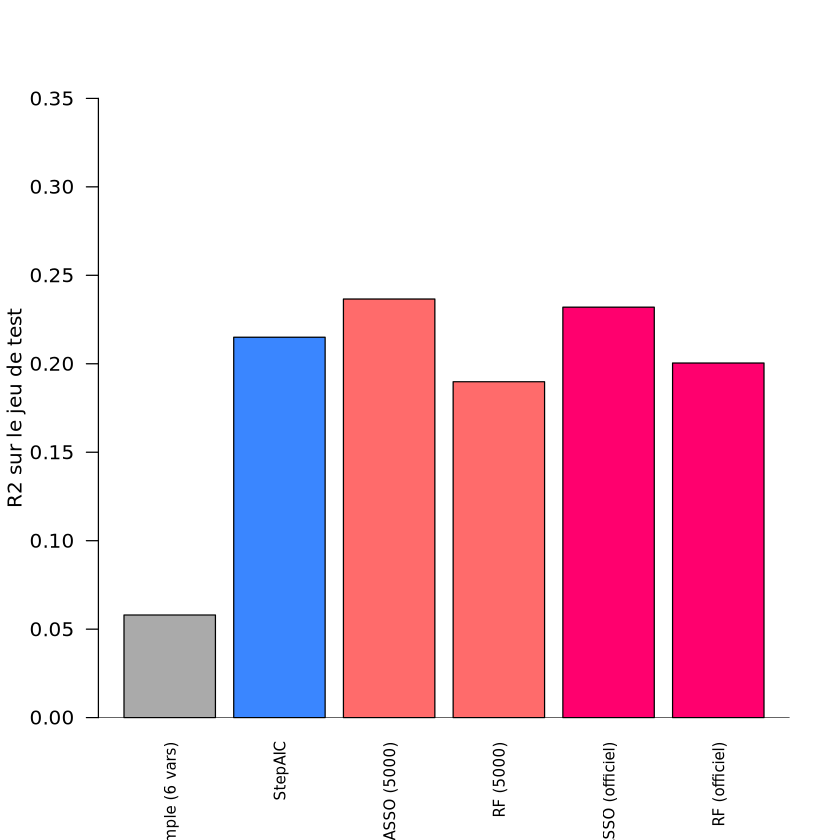

In [46]:
couleurs <- c("#AAAAAA", "#3A86FF", "#FF6B6B", "#FF6B6B",
              "#FF006E", "#FF006E")
barplot(resultats$R2,
        names.arg = resultats$Modele,
        col       = couleurs,
        las       = 2,
        cex.names = 0.75,
        ylim      = c(0, 0.35),
        ylab      = "R2 sur le jeu de test",
        main      = "")
abline(h = 0, col = "black")

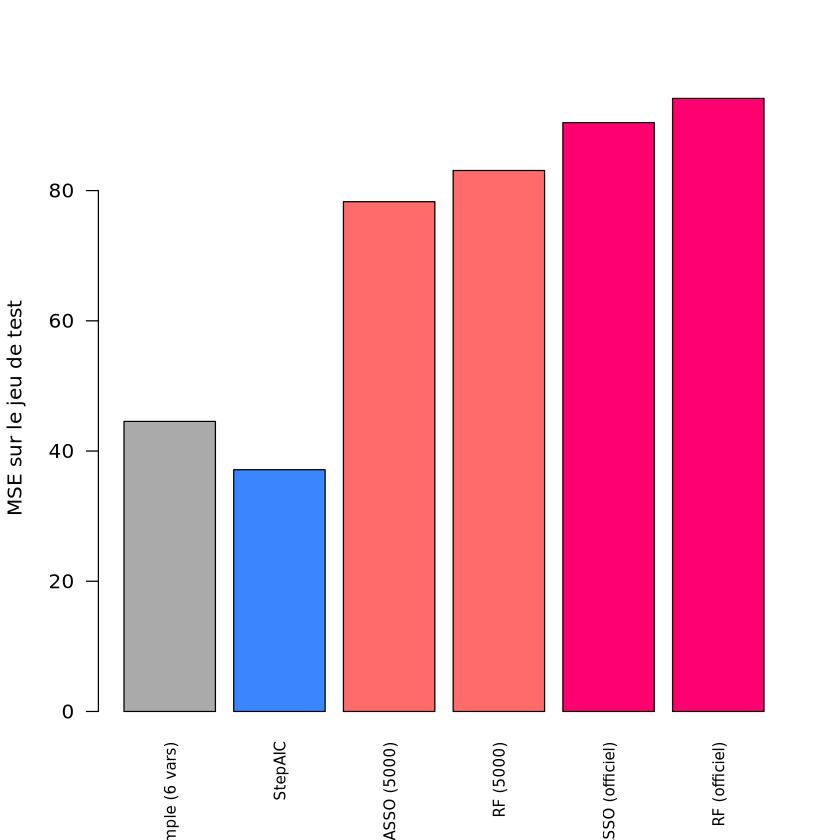

In [47]:
barplot(resultats$MSE,
        names.arg = resultats$Modele,
        col       = couleurs,
        las       = 2,
        cex.names = 0.75,
        ylab      = "MSE sur le jeu de test",
        main      = "")

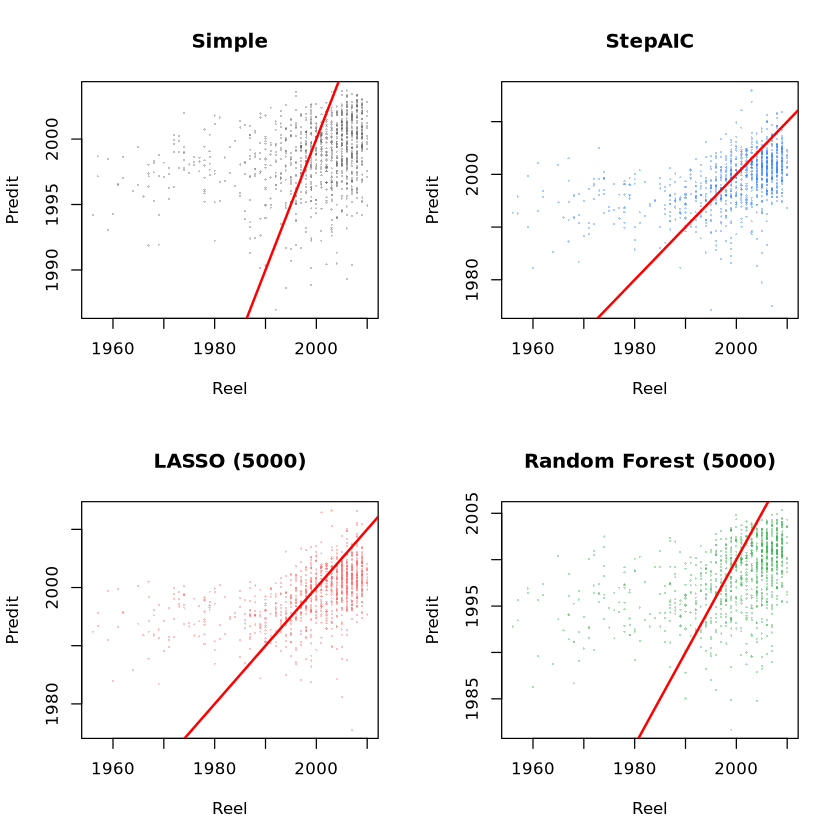

In [48]:
par(mfrow = c(2, 2))

plot(reduce.test$Year, predict(modSimple, newdata = reduce.test),
     xlab = "Reel", ylab = "Predit", main = "Simple",
     pch = 16, cex = 0.3, col = rgb(0.4, 0.4, 0.4, 0.4))
abline(0, 1, col = "red", lwd = 2)

plot(reduce.test$Year, predict(modStep, newdata = reduce.test),
     xlab = "Reel", ylab = "Predit", main = "StepAIC",
     pch = 16, cex = 0.3, col = rgb(0.2, 0.5, 1, 0.4))
abline(0, 1, col = "red", lwd = 2)

plot(reduce.test$Year, as.vector(predict(cvfit, newx = as.matrix(reduce.test[,-1]), s = "lambda.min")),
     xlab = "Reel", ylab = "Predit", main = "LASSO (5000)",
     pch = 16, cex = 0.3, col = rgb(1, 0.4, 0.4, 0.4))
abline(0, 1, col = "red", lwd = 2)

plot(reduce.test$Year, predict(mod_rf, newdata = reduce.test),
     xlab = "Reel", ylab = "Predit", main = "Random Forest (5000)",
     pch = 16, cex = 0.3, col = rgb(0.2, 0.7, 0.3, 0.4))
abline(0, 1, col = "red", lwd = 2)

par(mfrow = c(1, 1))

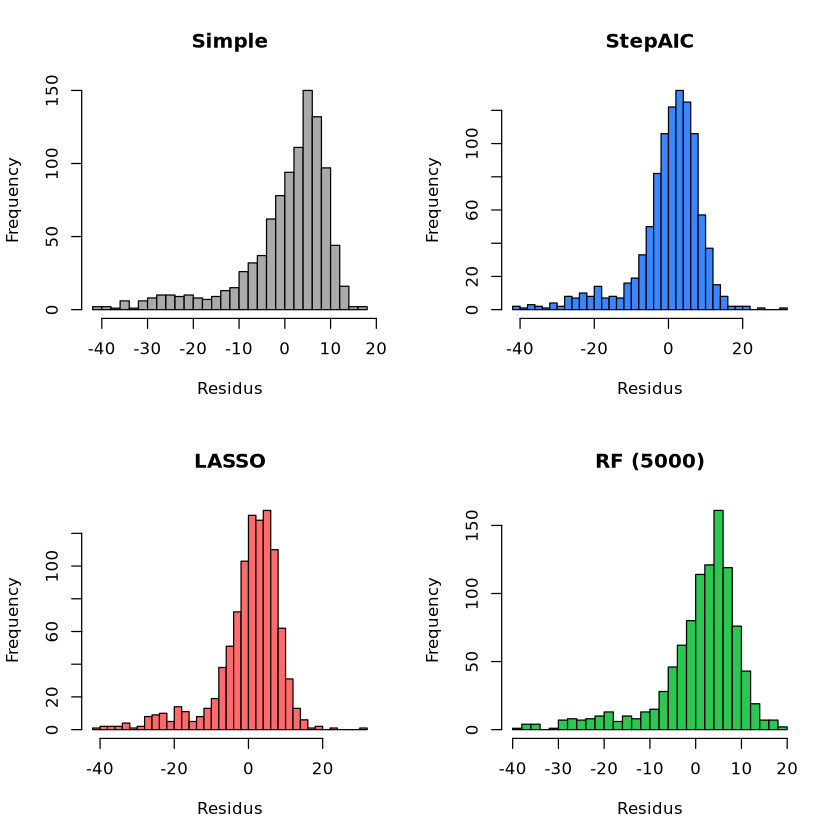

In [49]:
res_simple <- reduce.test$Year - predict(modSimple, newdata = reduce.test)
res_step   <- reduce.test$Year - predict(modStep,   newdata = reduce.test)
res_lasso  <- reduce.test$Year - as.vector(predict(cvfit, newx = as.matrix(reduce.test[,-1]), s = "lambda.min"))
res_rf     <- reduce.test$Year - predict(mod_rf, newdata = reduce.test)

par(mfrow = c(2, 2))

hist(res_simple, breaks = 30, col = "#AAAAAA", main = "Simple",   xlab = "Residus")
hist(res_step,   breaks = 30, col = "#3A86FF", main = "StepAIC",  xlab = "Residus")
hist(res_lasso,  breaks = 30, col = "#FF6B6B", main = "LASSO",    xlab = "Residus")
hist(res_rf,     breaks = 30, col = "#2DC653", main = "RF (5000)", xlab = "Residus")

par(mfrow = c(1, 1))